In [10]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.datasets import fetch_california_housing
import matplotlib.pyplot as plt

california_housing = fetch_california_housing(as_frame=True)
X = california_housing.data
y = california_housing.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

n_trees = range(1, 1001, 50)

max_features_values = [2, 6]
rf_results = {m: [] for m in max_features_values}

max_depth_values = [4, 6]
gbm_results = {depth: [] for depth in max_depth_values}

Random Forests

In [11]:
for m in max_features_values:
    for n in n_trees:
        rf = RandomForestRegressor(n_estimators=n, max_features=m, random_state=42)
        rf.fit(X_train, y_train)
        y_pred = rf.predict(X_test)
        mae = mean_absolute_error(y_test, y_pred)
        rf_results[m].append(mae)


Gradient Boosting Trees

In [12]:
for depth in max_depth_values:
    for n in n_trees:
        gbm = GradientBoostingRegressor(n_estimators=n, max_depth=depth, random_state=42)
        gbm.fit(X_train, y_train)
        y_pred = gbm.predict(X_test)
        mae = mean_absolute_error(y_test, y_pred)
        gbm_results[depth].append(mae)


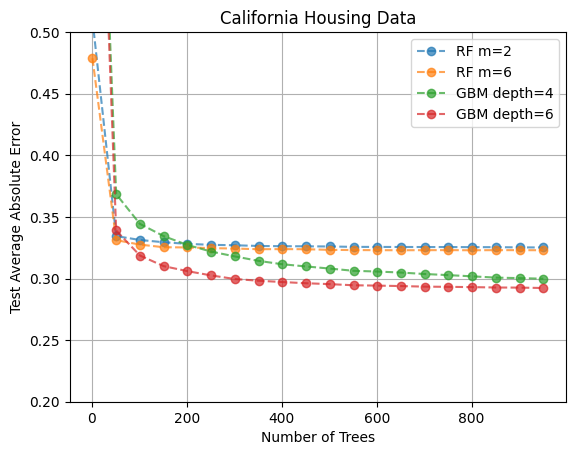

In [13]:
for m, errors in rf_results.items():
    plt.plot(list(n_trees), errors[:len(n_trees)], label=f'RF m={m}', linestyle='--', marker='o', alpha=0.7)

for m, errors in gbm_results.items():
    plt.plot(list(n_trees), errors[:len(n_trees)], label=f'GBM depth={m}', linestyle='--', marker='o', alpha=0.7)

plt.xlabel("Number of Trees")
plt.ylabel("Test Average Absolute Error")
plt.title("California Housing Data")
plt.legend()
plt.ylim(0.20, 0.5)
plt.grid()
plt.show()

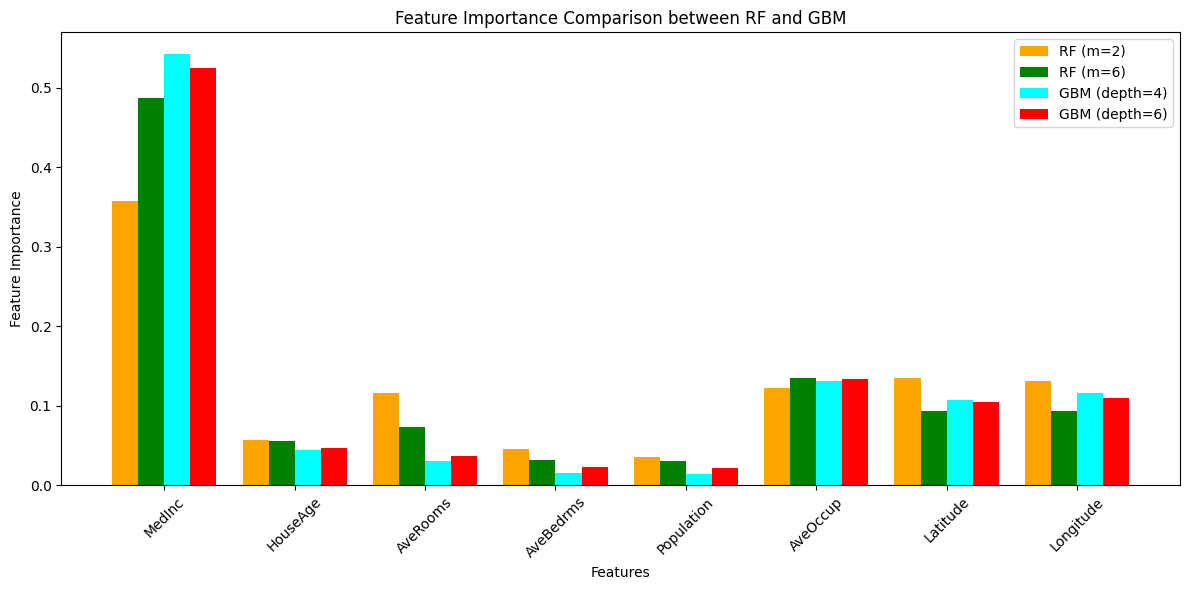


Feature Importance Rankings:

RF (m=2):
MedInc: 0.357
Latitude: 0.135
Longitude: 0.132
AveOccup: 0.122
AveRooms: 0.117
HouseAge: 0.057
AveBedrms: 0.046
Population: 0.035

RF (m=6):
MedInc: 0.487
AveOccup: 0.134
Latitude: 0.094
Longitude: 0.094
AveRooms: 0.073
HouseAge: 0.056
AveBedrms: 0.032
Population: 0.030

GBM (depth=4):
MedInc: 0.543
AveOccup: 0.131
Longitude: 0.116
Latitude: 0.108
HouseAge: 0.044
AveRooms: 0.031
AveBedrms: 0.015
Population: 0.014

GBM (depth=6):
MedInc: 0.524
AveOccup: 0.133
Longitude: 0.110
Latitude: 0.105
HouseAge: 0.046
AveRooms: 0.037
AveBedrms: 0.023
Population: 0.021

Correlation between feature importances of different models:
               RF (m=2)  RF (m=6)  GBM (depth=4)  GBM (depth=6)
RF (m=2)       1.000000  0.971929       0.971571       0.970034
RF (m=6)       0.971929  1.000000       0.994778       0.996010
GBM (depth=4)  0.971571  0.994778       1.000000       0.999830
GBM (depth=6)  0.970034  0.996010       0.999830       1.000000


In [ ]:
feature_names = california_housing.feature_names

rf_m2 = RandomForestRegressor(n_estimators=1000, max_features=2, random_state=42)
rf_m6 = RandomForestRegressor(n_estimators=1000, max_features=6, random_state=42)
gbm_d4 = GradientBoostingRegressor(n_estimators=1000, max_depth=4, random_state=42)
gbm_d6 = GradientBoostingRegressor(n_estimators=1000, max_depth=6, random_state=42)

models = {'RF (m=2)': rf_m2, 'RF (m=6)': rf_m6, 
          'GBM (depth=4)': gbm_d4, 'GBM (depth=6)': gbm_d6}

for name, model in models.items():
    model.fit(X_train, y_train)

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'RF (m=2)': rf_m2.feature_importances_,
    'RF (m=6)': rf_m6.feature_importances_,
    'GBM (depth=4)': gbm_d4.feature_importances_,
    'GBM (depth=6)': gbm_d6.feature_importances_
})

plt.figure(figsize=(12, 6))
x = np.arange(len(feature_names))
width = 0.2

plt.bar(x - 1.5*width, importance_df['RF (m=2)'], width, label='RF (m=2)', color='orange')
plt.bar(x - 0.5*width, importance_df['RF (m=6)'], width, label='RF (m=6)', color='green')
plt.bar(x + 0.5*width, importance_df['GBM (depth=4)'], width, label='GBM (depth=4)', color='cyan')
plt.bar(x + 1.5*width, importance_df['GBM (depth=6)'], width, label='GBM (depth=6)', color='red')

plt.xlabel('Features')
plt.ylabel('Feature Importance')
plt.title('Feature Importance Comparison between RF and GBM')
plt.xticks(x, feature_names, rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

print("\nFeature Importance Rankings:")
for model in ['RF (m=2)', 'RF (m=6)', 'GBM (depth=4)', 'GBM (depth=6)']:
    print(f"\n{model}:")
    sorted_importance = importance_df.sort_values(by=model, ascending=False)
    for _, row in sorted_importance.iterrows():
        print(f"{row['Feature']}: {row[model]:.3f}")

importance_corr = importance_df.iloc[:, 1:].corr()
print("\nCorrelation between feature importances of different models:")
print(importance_corr)

The feature importance comparison between RF and GBM shows similar patterns across both algorithms. Both methods identify Median Income as the dominant predictor, which is about 35-50% of importance, with only modest variations between them. The remaining features follow a consistent pattern of relative importance across both algorithms, with geographical features (Latitude, Longitude) and housing characteristics (AveRooms) being second most important predictors. These similarities suggest that both RF and GBM are capturing fundamentally similar relationships in the California housing data, despite their different algorithmic approaches.